In [8]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [9]:
def load_boston_housing_data():
    
    # Load CSV file (make sure file is in same folder)
    df = pd.read_csv("HousingData.csv")

    # Handle missing values (important for this dataset)
    df = df.fillna(df.mean())

    # Split features and target
    X = df.iloc[:, :-1].values   # all columns except last
    y = df.iloc[:, -1].values    # last column (MEDV)

    # Normalize data
    scaler_X = StandardScaler()
    scaler_y = StandardScaler()

    X = scaler_X.fit_transform(X)
    y = scaler_y.fit_transform(y.reshape(-1, 1)).flatten()

    return X, y, scaler_y


# Load data
X, y, scaler_y = load_boston_housing_data()

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)


# Convert to float32 (important)
X_train = X_train.astype('float32')
X_val = X_val.astype('float32')
X_test = X_test.astype('float32')

y_train = y_train.astype('float32')
y_val = y_val.astype('float32')
y_test = y_test.astype('float32')

In [11]:
batch_size = 32

train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train)) \
    .shuffle(buffer_size=len(X_train)) \
    .batch(batch_size) \
    .prefetch(tf.data.AUTOTUNE)

val_dataset = tf.data.Dataset.from_tensor_slices((X_val, y_val)) \
    .batch(batch_size) \
    .prefetch(tf.data.AUTOTUNE)

test_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test)) \
    .batch(batch_size) \
    .prefetch(tf.data.AUTOTUNE)

In [12]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train.shape[1],)),  # dynamic input

    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.BatchNormalization(),

    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.BatchNormalization(),

    tf.keras.layers.Dense(16, activation='relu'),

    tf.keras.layers.Dense(1)  # Linear output (regression)
])


# Compile model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

In [13]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=20,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=10,
        min_lr=0.00001,
        verbose=1
    )
]


In [14]:
history = model.fit(
    train_dataset,
    epochs=200,
    validation_data=val_dataset,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 2.8674 - mae: 1.2407 - val_loss: 0.5769 - val_mae: 0.5798 - learning_rate: 0.0010
Epoch 2/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.9215 - mae: 0.7535 - val_loss: 0.4853 - val_mae: 0.4951 - learning_rate: 0.0010
Epoch 3/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5603 - mae: 0.5745 - val_loss: 0.4883 - val_mae: 0.4859 - learning_rate: 0.0010
Epoch 4/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5123 - mae: 0.5387 - val_loss: 0.5029 - val_mae: 0.5036 - learning_rate: 0.0010
Epoch 5/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3926 - mae: 0.4674 - val_loss: 0.5192 - val_mae: 0.5198 - learning_rate: 0.0010
Epoch 6/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3088 - mae: 0.4232 - val_loss: 0.5362 - val_mae: 0.5329 - learning_rate: 0.0010
Epoch 7/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2820 - mae: 0.3839 - val_loss: 0.5222 - val_mae: 0.5304 - learning_rate: 0.0010
Epoch 8/200


In [15]:
test_loss, test_mae = model.evaluate(test_dataset)

print("\nTest Loss (MSE):", test_loss)
print("Test MAE:", test_mae)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2099 - mae: 0.2884 

Test Loss (MSE): 0.20992638170719147
Test MAE: 0.28838858008384705


In [16]:
predictions = model.predict(test_dataset)

# Convert back to original scale
predictions_rescaled = scaler_y.inverse_transform(predictions)
y_test_rescaled = scaler_y.inverse_transform(y_test.reshape(-1, 1))

print("\nSample Predictions:")
for i in range(5):
    print(f"Predicted: {predictions_rescaled[i][0]:.2f}, Actual: {y_test_rescaled[i][0]:.2f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step

Sample Predictions:
Predicted: 30.86, Actual: 23.60
Predicted: 31.34, Actual: 32.40
Predicted: 17.36, Actual: 13.60
Predicted: 25.78, Actual: 22.80
Predicted: 16.09, Actual: 16.10


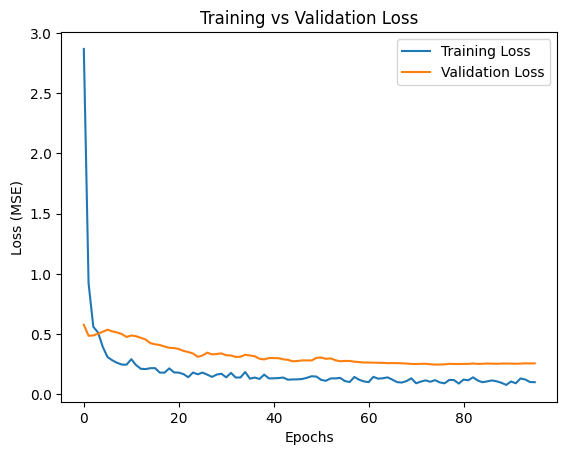

In [17]:

plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

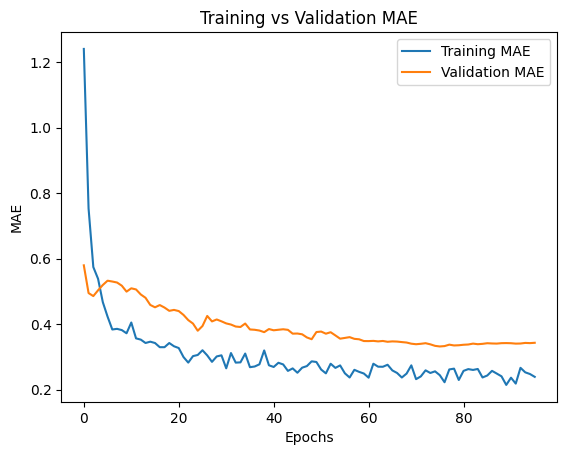

In [18]:
plt.figure()
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.title('Training vs Validation MAE')
plt.legend()
plt.show()